# Notebook 2

This notebook will simulate narrow escape problem for different dimensions and check results for different geometries

# 1 Dimension

A first example where we compare the exit time with respect to the amplitude of the space for a 1D movement

In [1]:
import numpy as np
from src.brownian import BrownianMotion
from src.surface import Surface
from src.naive_narrow_escape import NaiveNarrowEscape
from src.escape import Escape
from src.statistics import Statistics
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

def run_one_simulation(size):
    bm = BrownianMotion(num_steps=1000, delta_t=0.001)
    surface = Surface(name='line segment', functions=[lambda x: x[0]**2 - size**2])
    escape = Escape([lambda x: True])
    naive_narrow_escape = NaiveNarrowEscape(bm, surface, [escape])

    escape_point, escape_time = naive_narrow_escape.run_simulation_straight_exit()
    return escape_point, escape_time

Sizes:   0%|          | 0/45 [00:00<?, ?it/s]

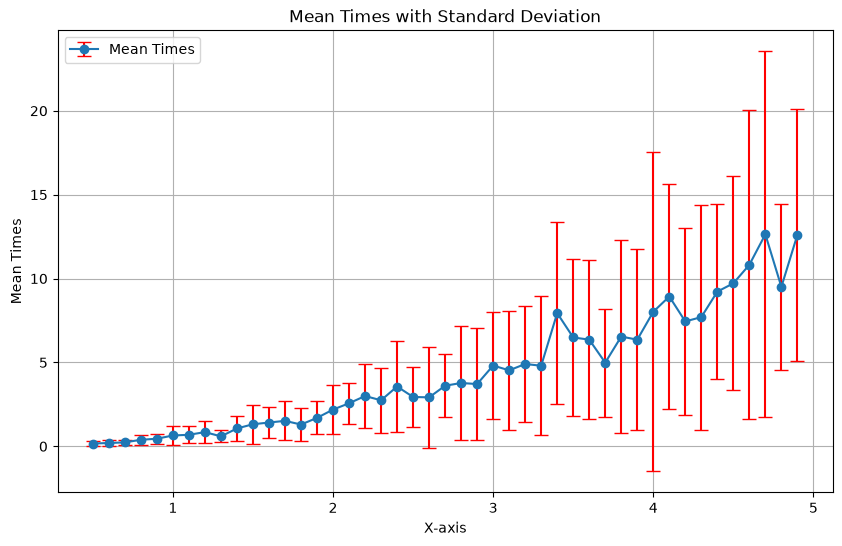

In [2]:
x_axis = np.arange(0.5, 5, 0.1)
mean_escape_times = []
dev_escape_times = []

for size in tqdm(x_axis, desc="Sizes"):
    escape_times = []
    exit_points = []

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(size)
        for _ in range(20)
    )

    for escape_point, escape_time in results:
        if escape_point is not None:
            escape_times.append(escape_time)
            exit_points.append(escape_point)

    escape_times = np.array(escape_times)
    exit_points = np.array(exit_points)

    mean_escape_time = np.mean(escape_times)
    mean_escape_times.append(mean_escape_time)

    dev_escape_time = np.std(escape_times)
    dev_escape_times.append(dev_escape_time)

Statistics.plot_mean_times(x_axis, mean_escape_times, dev_escape_times)

## 2 Dimensions

In [ ]:
import numpy as np
from src.brownian import BrownianMotion
from src.surface import Surface
from src.naive_narrow_escape import NaiveNarrowEscape
from src.escape import Escape
from src.statistics import Statistics
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

def run_one_simulation_2d(size):
    bm = BrownianMotion(num_steps=10000, delta_t=0.0001, dimension=2)

    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])
    escape = Escape([lambda x: np.abs(x[1]) < size / 2])  # Escape condition: y-coordinate within the narrow escape region
    naive_narrow_escape = NaiveNarrowEscape(bm, surface, [escape])

    escape_point, escape_time = naive_narrow_escape.run_simulation_straight_exit()
    return escape_point, escape_time

Sizes:   0%|          | 0/30 [00:00<?, ?it/s]

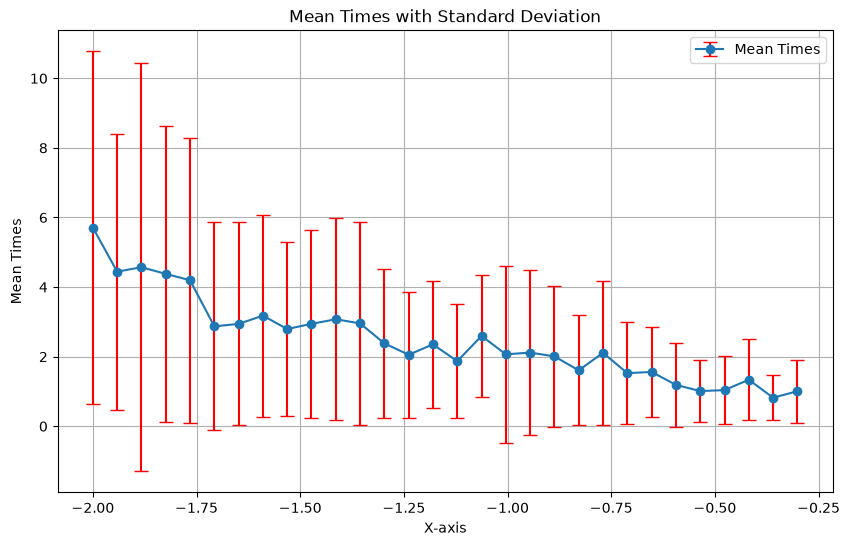

In [ ]:
x_axis = np.logspace(np.log10(0.5), np.log10(0.01), num=30, endpoint=True)
mean_escape_times = []
dev_escape_times = []

for size in tqdm(x_axis, desc="Sizes"):
    escape_times = []
    exit_points = []

    
    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation_2d)(size)
        for _ in range(50)
    )

    for escape_point, escape_time in results:
        if escape_point is not None:
            escape_times.append(escape_time)
            exit_points.append(escape_point)

    escape_times = np.array(escape_times)
    exit_points = np.array(exit_points)

    mean_escape_time = np.mean(escape_times)
    mean_escape_times.append(mean_escape_time)

    dev_escape_time = np.std(escape_times)
    dev_escape_times.append(dev_escape_time)

Statistics.plot_mean_times(np.log10(x_axis), mean_escape_times, dev_escape_times, xlabel='log(ε)')

One simulation graphically

Escape time: 1.5357500000000002


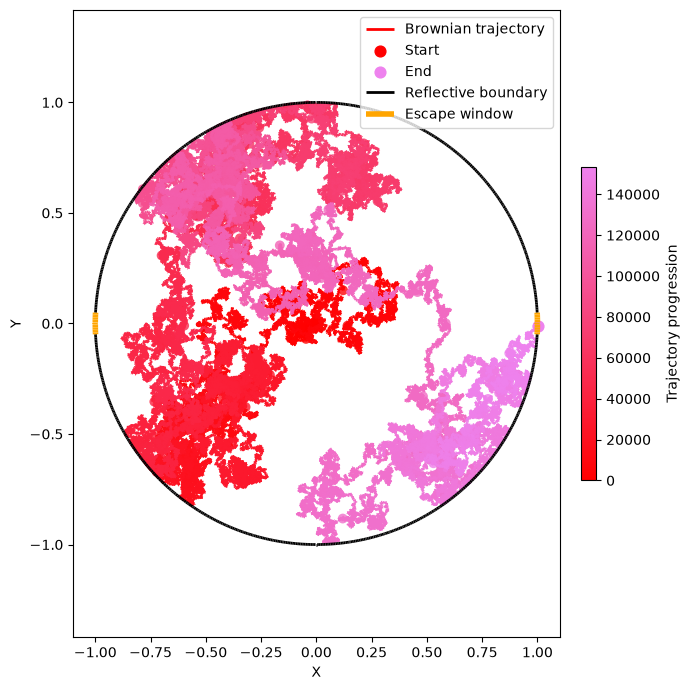

In [2]:
import numpy as np
from src.brownian import BrownianMotion
from src.surface import Surface
from src.naive_narrow_escape import NaiveNarrowEscape
from src.escape import Escape

bm = BrownianMotion(num_steps=10000, delta_t=0.00001, dimension=2)

# Surface defined by the equation x^2 + y^2 = 1 (unit circle)
surface = Surface(name='line segment', functions=[lambda x: x[0]**2 + x[1]**2 - 1])
escape = Escape([lambda x: np.abs(x[1]) < 0.1 / 2])  # Escape condition: y-coordinate within the narrow escape region
naive_narrow_escape = NaiveNarrowEscape(bm, surface, [escape])

escape_point, escape_time = naive_narrow_escape.run_simulation_straight_exit()

print(f'Escape time: {escape_time}')
naive_narrow_escape.plot_narrow_escape_problem()